In [ ]:
import sys, os, pickle, io
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm

PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'toy_domain'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'TrapGrid'))
import trap_grid_env

CONT_RUN_NAME = 'trapgrid_cont'
CONT_RUN_DIR  = os.path.join(PROJECT_ROOT, 'runs', CONT_RUN_NAME)

N_TAU       = 32
ALPHA       = 0.2
DELTA_D     = -0.5
DELTA_R     =  0.5
DEVICE      = 'cpu'
SIZE        = 10.0

FIXED_STATE = [10.0, 0.0]   # the state used for all evaluations

# Focus centres for action sampling
START_CENTER  = np.array([10.0, 0.0])   # near the start
MIDDLE_CENTER = np.array([5.0,  5.0])   # grid centre (recovery/trap zone)

N_ACTIONS = 3000   # samples per scatter plot
SIGMA     = 1.5    # std-dev of Gaussian focus (in grid units)

print(f'Fixed state : {FIXED_STATE}')
print(f'N_ACTIONS={N_ACTIONS}, sigma={SIGMA}')

## 1. Load Continuous Agents

In [2]:
class CpuUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(
                io.BytesIO(b), map_location=torch.device('cpu'), weights_only=False
            )
        return super().find_class(module, name)

def load_pkl(path):
    with open(path, 'rb') as f:
        return CpuUnpickler(f).load()

def prep_cont_net(ded_agent, device=DEVICE):
    """Move all device-bound tensors to the target device."""
    net = ded_agent.qnetwork_local
    net.to(device)
    net.device = device
    for attr in ('pis', '_s_mean', '_s_scale', '_a_mean', '_a_scale'):
        if hasattr(net, attr):
            setattr(net, attr, getattr(net, attr).to(device))
    return net


c_agent = c_qd = c_qr = None
try:
    c_agent = load_pkl(os.path.join(CONT_RUN_DIR, f'{CONT_RUN_NAME}_agent.pkl'))
    c_qd    = load_pkl(os.path.join(CONT_RUN_DIR, f'{CONT_RUN_NAME}_Qd.pkl'))
    c_qr    = load_pkl(os.path.join(CONT_RUN_DIR, f'{CONT_RUN_NAME}_Qr.pkl'))
    print(f'Loaded continuous agents from {CONT_RUN_DIR}')
    print(f'  Qd network: {type(c_qd.qnetwork_local).__name__}')
    print(f'  Qr network: {type(c_qr.qnetwork_local).__name__}')
except FileNotFoundError as e:
    print(f'Agents not found: {e}')

Loaded continuous agents from /home/jay/Uni/SafetyResearch/runs/trapgrid_cont
  Qd network: ContinuousIQN
  Qr network: ContinuousIQN


## 2. Helpers

Focused sampling draws actions from a **clipped Gaussian** centred at a chosen point.
This concentrates samples in the region of interest while remaining random,
unlike a uniform sweep which spreads mass evenly across the full 10×10 space.

In [3]:
def sample_actions_focused(center, n=N_ACTIONS, sigma=SIGMA, seed=42):
    """Sample n actions from a Gaussian centred at `center`, clipped to [0, SIZE]."""
    rng = np.random.default_rng(seed)
    actions = rng.normal(loc=center, scale=sigma, size=(n, 2)).astype(np.float32)
    return np.clip(actions, 0.0, SIZE)


def compute_cvar_scatter(ded_agent, actions, state=FIXED_STATE,
                         n_tau=N_TAU, eta=ALPHA, device=DEVICE):
    """Evaluate CVaR for each (state, action) pair.
    Returns cvar array of shape (n_actions,).
    """
    n_keep  = max(1, int(eta * n_tau))
    network = prep_cont_net(ded_agent, device)
    network.eval()

    states  = np.tile(np.array([state], dtype=np.float32), (len(actions), 1))
    s_t = torch.from_numpy(states).to(device)
    a_t = torch.from_numpy(actions).to(device)

    with torch.no_grad():
        quantiles, _ = network.forward(s_t, a_t, num_tau=n_tau)

    q = quantiles.squeeze(-1).cpu().numpy()        # (N, n_tau)
    cvar = np.sort(q, axis=1)[:, :n_keep].mean(axis=1)
    return cvar


def plot_focused_scatter(cvar_d, cvar_r, actions, center, label, axes_row):
    """Plot Qd CVaR, Qr CVaR, and combined dead-end prediction for one focus region."""
    vmax_d = max(np.abs(cvar_d).max(), 1e-6)
    vmax_r = max(np.abs(cvar_r).max(), 1e-6)

    # Qd
    ax = axes_row[0]
    norm = TwoSlopeNorm(vmin=-vmax_d, vcenter=0, vmax=vmax_d)
    sc = ax.scatter(actions[:, 0], actions[:, 1], c=cvar_d,
                    cmap='RdBu', norm=norm, s=6, alpha=0.8)
    ax.figure.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label='CVaR')
    ax.axvline(center[0], color='k', lw=0.8, ls='--', alpha=0.5)
    ax.axhline(center[1], color='k', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlim(0, SIZE); ax.set_ylim(0, SIZE)
    ax.set_xlabel('action x'); ax.set_ylabel('action y')
    ax.set_title(f'CVaR($Q_d$) — actions near {label}\n'
                 f'state={FIXED_STATE}, σ={SIGMA}')

    # Qr
    ax = axes_row[1]
    norm = TwoSlopeNorm(vmin=-vmax_r, vcenter=0, vmax=vmax_r)
    sc = ax.scatter(actions[:, 0], actions[:, 1], c=cvar_r,
                    cmap='RdBu', norm=norm, s=6, alpha=0.8)
    ax.figure.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label='CVaR')
    ax.axvline(center[0], color='k', lw=0.8, ls='--', alpha=0.5)
    ax.axhline(center[1], color='k', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlim(0, SIZE); ax.set_ylim(0, SIZE)
    ax.set_xlabel('action x'); ax.set_ylabel('action y')
    ax.set_title(f'CVaR($Q_r$) — actions near {label}\n'
                 f'state={FIXED_STATE}, σ={SIGMA}')

    # Combined dead-end prediction
    ax = axes_row[2]
    dead = (cvar_d <= DELTA_D) & (cvar_r <= DELTA_R)
    colors = np.where(dead[:, None],
                      [[231/255, 76/255, 60/255, 0.8]],
                      [[1.0, 1.0, 1.0, 0.5]])
    ax.scatter(actions[:, 0], actions[:, 1],
               c=colors.reshape(-1, 4), s=6)
    ax.axvline(center[0], color='k', lw=0.8, ls='--', alpha=0.5)
    ax.axhline(center[1], color='k', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlim(0, SIZE); ax.set_ylim(0, SIZE)
    ax.set_xlabel('action x'); ax.set_ylabel('action y')
    legend_patches = [
        mpatches.Patch(color='#e74c3c', label=f'Dead-end (CVaR$_D$≤{DELTA_D} & CVaR$_R$≤{DELTA_R})'),
        mpatches.Patch(color='white',   label='Safe', ec='grey'),
    ]
    ax.legend(handles=legend_patches, fontsize=7, framealpha=0.9)
    ax.set_title(f'Combined dead-end — actions near {label}\n'
                 f'state={FIXED_STATE}, σ={SIGMA}')
    pct = dead.mean() * 100
    ax.text(0.02, 0.02, f'{pct:.1f}% predicted dead-end',
            transform=ax.transAxes, fontsize=8, va='bottom')


print('Helpers defined.')

Helpers defined.


## 3. Actions Focused Around the Start Point (10.0, 0.0)

Samples actions from $\mathcal{N}(\mu=[10.0, 0.0],\, \sigma=1.5)$ clipped to $[0,10]^2$,
evaluated at state $(10, 0)$.

The neutral zone is now $x \in [9,10]$, $y \in [0,1]$ (1×1 square); everything outside is Death Zone.
We expect $Q_d$ to be strongly negative and $Q_r$ to be near zero across most of this region.

Sampled 3000 actions around start [9.9 0.1]
  x range: [4.05, 10.00]
  y range: [0.00, 4.99]
Computing CVaR(Qd)...
  range: [-1.0043, -0.9981]
  mean:  -1.0010
Computing CVaR(Qr)...
  range: [-0.0011, -0.0004]
  mean:  -0.0008


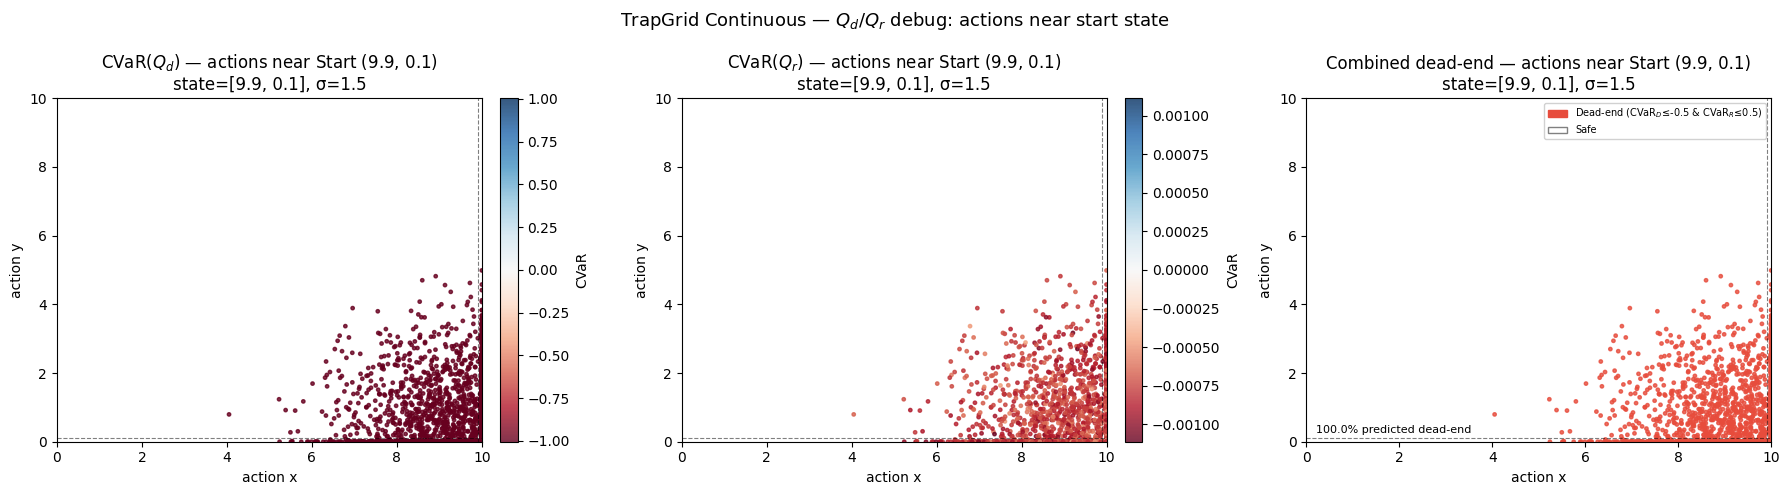

Saved to /home/jay/Uni/SafetyResearch/runs/trapgrid_cont/debug_scatter_start.png


In [4]:
if c_qd is not None and c_qr is not None:
    actions_start = sample_actions_focused(START_CENTER, seed=0)
    print(f'Sampled {len(actions_start)} actions around start {START_CENTER}')
    print(f'  x range: [{actions_start[:,0].min():.2f}, {actions_start[:,0].max():.2f}]')
    print(f'  y range: [{actions_start[:,1].min():.2f}, {actions_start[:,1].max():.2f}]')

    print('Computing CVaR(Qd)...')
    cvar_d_start = compute_cvar_scatter(c_qd, actions_start)
    print(f'  range: [{cvar_d_start.min():.4f}, {cvar_d_start.max():.4f}]')
    print(f'  mean:  {cvar_d_start.mean():.4f}')

    print('Computing CVaR(Qr)...')
    cvar_r_start = compute_cvar_scatter(c_qr, actions_start)
    print(f'  range: [{cvar_r_start.min():.4f}, {cvar_r_start.max():.4f}]')
    print(f'  mean:  {cvar_r_start.mean():.4f}')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    plot_focused_scatter(cvar_d_start, cvar_r_start, actions_start,
                         center=START_CENTER, label='Start (9.9, 0.1)', axes_row=axes)
    fig.suptitle(f'TrapGrid Continuous — $Q_d$/$Q_r$ debug: actions near start state', fontsize=13)
    plt.tight_layout()
    out_path = os.path.join(CONT_RUN_DIR, 'debug_scatter_start.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to', out_path)
else:
    print('Skipped — agents not loaded.')

## 4. Actions Focused Around the Centre (5.0, 5.0)

Samples actions from $\mathcal{N}(\mu=[5.0, 5.0],\, \sigma=1.5)$ clipped to $[0,10]^2$,
evaluated at state $(10, 0)$.

This region contains the **Recovery Zone** (r≤0.25) surrounded by the **Trap annulus** (r≤1.0).
We expect $Q_r$ to be positive near the recovery centre and $Q_d$ to distinguish the trap
boundary from the surrounding death zone.

Sampled 3000 actions around centre [5. 5.]
  x range: [0.00, 10.00]
  y range: [0.13, 9.95]
Computing CVaR(Qd)...
  range: [-1.0098, -0.0309]
  mean:  -0.9899
Computing CVaR(Qr)...
  range: [-0.0042, 0.9772]
  mean:  0.0127


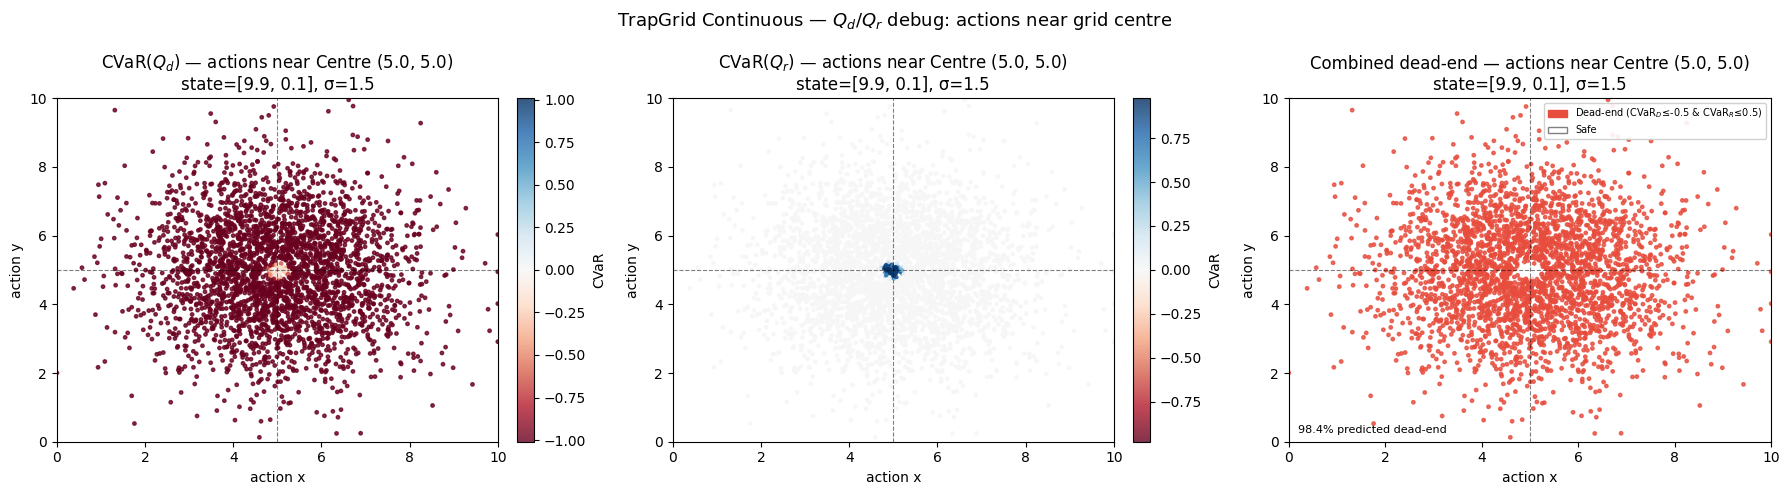

Saved to /home/jay/Uni/SafetyResearch/runs/trapgrid_cont/debug_scatter_centre.png


In [5]:
if c_qd is not None and c_qr is not None:
    actions_mid = sample_actions_focused(MIDDLE_CENTER, seed=1)
    print(f'Sampled {len(actions_mid)} actions around centre {MIDDLE_CENTER}')
    print(f'  x range: [{actions_mid[:,0].min():.2f}, {actions_mid[:,0].max():.2f}]')
    print(f'  y range: [{actions_mid[:,1].min():.2f}, {actions_mid[:,1].max():.2f}]')

    print('Computing CVaR(Qd)...')
    cvar_d_mid = compute_cvar_scatter(c_qd, actions_mid)
    print(f'  range: [{cvar_d_mid.min():.4f}, {cvar_d_mid.max():.4f}]')
    print(f'  mean:  {cvar_d_mid.mean():.4f}')

    print('Computing CVaR(Qr)...')
    cvar_r_mid = compute_cvar_scatter(c_qr, actions_mid)
    print(f'  range: [{cvar_r_mid.min():.4f}, {cvar_r_mid.max():.4f}]')
    print(f'  mean:  {cvar_r_mid.mean():.4f}')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    plot_focused_scatter(cvar_d_mid, cvar_r_mid, actions_mid,
                         center=MIDDLE_CENTER, label='Centre (5.0, 5.0)', axes_row=axes)
    fig.suptitle(f'TrapGrid Continuous — $Q_d$/$Q_r$ debug: actions near grid centre', fontsize=13)
    plt.tight_layout()
    out_path = os.path.join(CONT_RUN_DIR, 'debug_scatter_centre.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to', out_path)
else:
    print('Skipped — agents not loaded.')

## 5. Raw Quantile Distributions at Specific Actions

Print the full quantile distribution of $Q_d$ and $Q_r$ at four hand-picked actions
to understand the uncertainty structure:

| Action | Expected region |
|--------|-----------------|
| (10.0, 0.0) | Neutral/start zone |
| (5.0, 5.0) | Recovery centre |
| (4.5, 5.0) | Trap annulus |
| (2.0, 2.0) | Death zone (trap forced state) |

In [ ]:
PROBE_ACTIONS = {
    'Neutral/start (10.0, 0.0)': [10.0, 0.0],
    'Recovery centre (5.0, 5.0)': [5.0, 5.0],
    'Trap annulus (4.5, 5.0)': [4.5, 5.0],
    'Death zone (2.0, 2.0)': [2.0, 2.0],
}

if c_qd is not None and c_qr is not None:
    net_d = prep_cont_net(c_qd)
    net_d.eval()
    net_r = prep_cont_net(c_qr)
    net_r.eval()

    n_keep = max(1, int(ALPHA * N_TAU))
    s_t = torch.tensor([FIXED_STATE], dtype=torch.float32)

    fig, axes = plt.subplots(len(PROBE_ACTIONS), 2,
                             figsize=(12, 3 * len(PROBE_ACTIONS)))

    for row, (label, action) in enumerate(PROBE_ACTIONS.items()):
        a_t = torch.tensor([action], dtype=torch.float32)
        with torch.no_grad():
            qd_out, _ = net_d.forward(s_t, a_t, num_tau=64)
            qr_out, _ = net_r.forward(s_t, a_t, num_tau=64)

        qd_q = np.sort(qd_out.squeeze().cpu().numpy())
        qr_q = np.sort(qr_out.squeeze().cpu().numpy())
        cvar_d = qd_q[:n_keep].mean()
        cvar_r = qr_q[:n_keep].mean()
        dead = (cvar_d <= DELTA_D) and (cvar_r <= DELTA_R)

        taus = np.linspace(0, 1, len(qd_q))

        axes[row, 0].plot(taus, qd_q, color='#e74c3c', lw=1.5)
        axes[row, 0].axhline(DELTA_D, color='black', lw=1, ls='--', label=f'δD={DELTA_D}')
        axes[row, 0].axhline(cvar_d, color='grey', lw=1, ls=':', label=f'CVaR={cvar_d:.3f}')
        axes[row, 0].fill_between(taus[:n_keep], qd_q[:n_keep], alpha=0.3, color='#e74c3c',
                                  label=f'CVaR tail (α={ALPHA})')
        axes[row, 0].set_title(f'$Q_d$ quantiles — {label}', fontsize=9)
        axes[row, 0].set_xlabel('τ'); axes[row, 0].set_ylabel('Q value')
        axes[row, 0].legend(fontsize=7)

        axes[row, 1].plot(taus, qr_q, color='#3498db', lw=1.5)
        axes[row, 1].axhline(DELTA_R, color='black', lw=1, ls='--', label=f'δR={DELTA_R}')
        axes[row, 1].axhline(cvar_r, color='grey', lw=1, ls=':', label=f'CVaR={cvar_r:.3f}')
        axes[row, 1].fill_between(taus[:n_keep], qr_q[:n_keep], alpha=0.3, color='#3498db',
                                  label=f'CVaR tail (α={ALPHA})')
        axes[row, 1].set_title(
            f'$Q_r$ quantiles — {label}  [dead-end={dead}]', fontsize=9)
        axes[row, 1].set_xlabel('τ'); axes[row, 1].set_ylabel('Q value')
        axes[row, 1].legend(fontsize=7)

        print(f'{label}: CVaR_D={cvar_d:.4f}  CVaR_R={cvar_r:.4f}  dead-end={dead}')

    plt.suptitle(f'TrapGrid — Quantile distributions at state {FIXED_STATE}', fontsize=13)
    plt.tight_layout()
    out_path = os.path.join(CONT_RUN_DIR, 'debug_quantiles.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to', out_path)
else:
    print('Skipped — agents not loaded.')